In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCC.csv")


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    b_std = 'd' + str(i)
    # b_std = 'b' + str(i) + '_std'
    b_name.append(b_std)


# b_name = np.array(b_name)
# b_name

In [4]:
# cols_rdmc = b_name + ["CWM_log10_LDMC", "DS_relative_abund_sum", "ES_relative_abund_sum", "F_relative_abund_sum", "G_relative_abund_sum", "M_relative_abund_sum"]
# cols_srl = b_name+ ["CWM_log10_SLA"]+ ["CWM_log10_LA"]+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rtd = b_name+ ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rd = b_name+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]


# cols_sra = b_name + ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rbd = b_name+ ["CWM_log10_LA"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rld = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rcc = b_name+ ["CWM_log10_PC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rd13c = b_name+ ["CWM_Ld13C"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rnc = b_name+ ["CWM_log10_PN"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rd15n = b_name+ ["CWM_Ld15N"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rcn = b_name+ ["CN_ratio"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

In [4]:
x_RDMC = np.array(df_svc_RDMC[b_name] )
x_SRL = np.array(df_svc_SRL[b_name])
x_RTD = np.array(df_svc_RTD[b_name])
x_RD = np.array(df_svc_RD[b_name])
x_SRA = np.array(df_svc_SRA[b_name])
x_RBD = np.array(df_svc_RBD[b_name])
x_RLD = np.array(df_svc_RLD[b_name])
x_RD13C = np.array(df_svc_RD13C[b_name])
x_RNC = np.array(df_svc_RNC[b_name])
x_RD15N = np.array(df_svc_RD15N[b_name])
x_RCN = np.array(df_svc_RCN[b_name])
x_RCC = np.array(df_svc_RCC[b_name])

In [5]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [6]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [7]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [8]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [9]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [10]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [11]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


Optimised number of PLS components:  14
Wavelengths to be kept  25
Optimised MSEP  44.392201634942474



[269.56500024 189.8651696  306.72971857 269.61139556 237.826044
 289.60116608 264.06696108 251.23810498 190.01159742 271.61970459
 280.61817973 195.21378837 287.87787383 242.99735277 325.18239924
 227.35561195 251.7570355  317.62561022 242.62559829 322.44508046
 293.92853454 231.36330714 375.07067159 219.6814045  251.30547407
 312.85303917 357.39302052 299.56868599 361.44992698 316.21205079
 259.99893105 396.29607654 347.67185563 388.40329003 349.13105481
 340.91221311 344.78657082 296.83107237 304.31637996 336.13482441
 342.14695988 361.14390705 334.02190663 332.55666219 337.62064885
 311.29251962 314.07518108 299.2921742  308.52036021 318.47736421
 303.47531651 310.88090376 334.72137216 327.30198129 322.13697348
 313.13712919 312.14119899 331.87194264 312.50993358 310.07027953
 308.29824654 281.04920913 283.72617864 356.31574483 344.06294312
 317.53371204 317.86742059 338.98575667 314.77351254 318.07494246
 286.05085242 328.77478042 297.53364935 305.3571182  321.55975498
 320.0658459

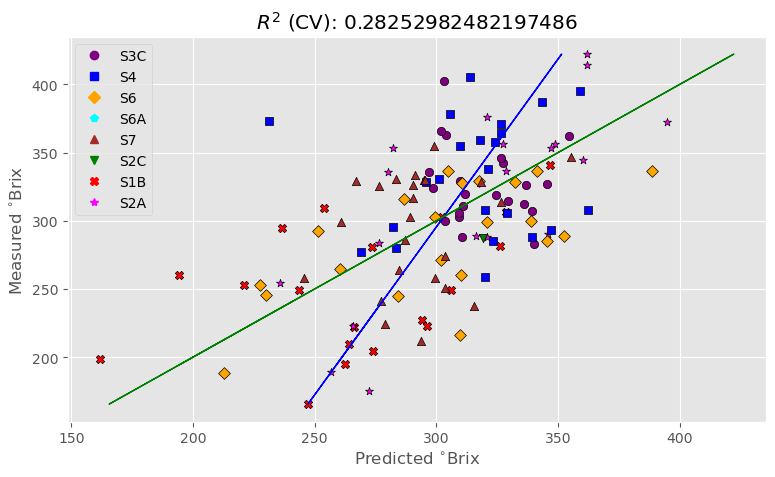

In [12]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)

## SRL

In [13]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  1
Wavelengths to be kept  36
Optimised MSEP  33.24524022119965



[ 99.52359126 111.9067257  100.63316182  98.64615632 114.93465354
 118.69781789  93.55580105 123.75424977 103.67681972 102.99375091
 104.59198146 100.34101586 104.64278884 103.95167153 112.40897582
 116.83604648 110.54213861 116.69247448 114.89390673  78.73525244
  77.02355474  48.05590938  61.51165762  52.75566884  74.85045273
  63.15712915  44.24643213  70.2416128   56.27768531  53.29937599
  35.6636803   63.53383259  47.57838645  49.48484415   8.09790886
  48.88608986  98.34973162 144.35701108 127.60361993 149.30547129
 131.75114542 150.61572028 134.00870715 138.59797324 141.06635818
 136.86040887 152.56036258 143.4194322  132.82159096 142.74420435
 132.40073115 127.56382258 138.46720169 130.73804355 136.65155644
 141.90499094 139.88283862 125.38099535 119.25673694 121.85960978
 136.84165123 138.50969422 128.94940199 131.8704845  126.45100485
 131.59523222 142.50478018 118.82961823 118.85640867 119.30858414
 126.79202028 131.92435831 124.9019823  121.11216047 135.7796854
 127.192656

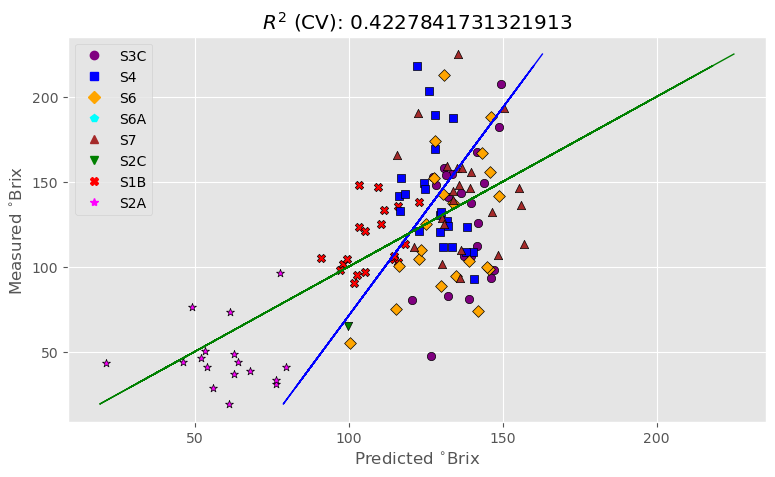

In [14]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

In [ ]:
optimal_pls = PLSRegression(n_components = ncomp)
optimal_pls.fit(opt_Xc, y_SRL.astype(np.float64))

coefficients = optimal_pls.coef_[:,0]
bands = band_name[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

In [ ]:
optimal_pls.intercept_


In [ ]:
bands

## RTD
 

In [15]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 25)


Optimised number of PLS components:  10
Wavelengths to be kept  27
Optimised MSEP  0.07363552538473865



[0.33265372 0.25167571 0.28361695 0.3381951  0.43283037 0.43269318
 0.39854375 0.33328562 0.43798772 0.47938048 0.47368117 0.40697179
 0.63331962 0.46825652 0.54887896 0.44102689 0.45290821 0.48813851
 0.47509472 0.35986742 0.27570902 0.35283995 0.63449134 0.56247744
 0.56743816 0.46611937 0.6152486  0.47923158 0.51866152 0.54573436
 0.3641685  0.64545244 0.4846343  0.41749706 0.56352189 0.23644253
 0.46023496 0.55132095 0.49998611 0.44849    0.48203101 0.44554236
 0.50648046 0.46111502 0.47792506 0.49612409 0.45960779 0.43679541
 0.50550434 0.48663909 0.48200861 0.445212   0.45405739 0.48020192
 0.49805061 0.47880738 0.45325521 0.49300177 0.52169161 0.50931687
 0.54600925 0.53710593 0.50985401 0.51266415 0.49844191 0.4784182
 0.51953106 0.53705288 0.54396704 0.52393149 0.4488764  0.48946708
 0.55855131 0.55576976 0.48126307 0.46198741 0.54607286 0.541251
 0.51795214 0.56990939 0.50493986 0.40058883 0.49091409 0.40158113
 0.44414125 0.4661376  0.46291985 0.46251436 0.46021438 0.4336472

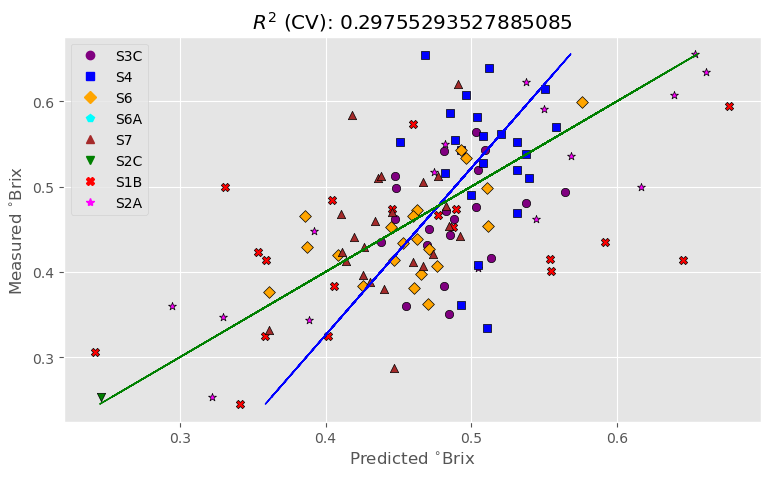

In [16]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [17]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 20)


Optimised number of PLS components:  13
Wavelengths to be kept  29
Optimised MSEP  0.028130448372495724



[0.13501642 0.13570835 0.13809842 0.12005082 0.1384568  0.15158277
 0.12477851 0.14382432 0.13797714 0.13822435 0.11962046 0.14459772
 0.13603402 0.13241894 0.14095195 0.14171737 0.15233338 0.13743651
 0.1522132  0.14434721 0.13980107 0.13958466 0.14975883 0.13607155
 0.15432761 0.13650513 0.13393022 0.15550978 0.15576356 0.13284202
 0.13194671 0.14912167 0.13008225 0.14772719 0.14727391 0.1302099
 0.16473826 0.14430523 0.14335276 0.14206908 0.14931795 0.13474015
 0.14078436 0.13331504 0.13560396 0.15037653 0.13767897 0.16229923
 0.13583421 0.15189195 0.15259819 0.13376569 0.15262839 0.14528845
 0.14504294 0.15370316 0.13698939 0.14959489 0.14621735 0.15729008
 0.14352665 0.14200788 0.15968922 0.15479181 0.14936224 0.16200638
 0.14001022 0.15646932 0.16160103 0.15210086 0.15819379 0.18396275
 0.14801186 0.16900174 0.14744965 0.1990555  0.15104117 0.16197659
 0.17167021 0.16108151 0.14773053 0.13182363 0.17141911 0.13518152
 0.15576957 0.17041773 0.13188456 0.16525446 0.1708956  0.14524

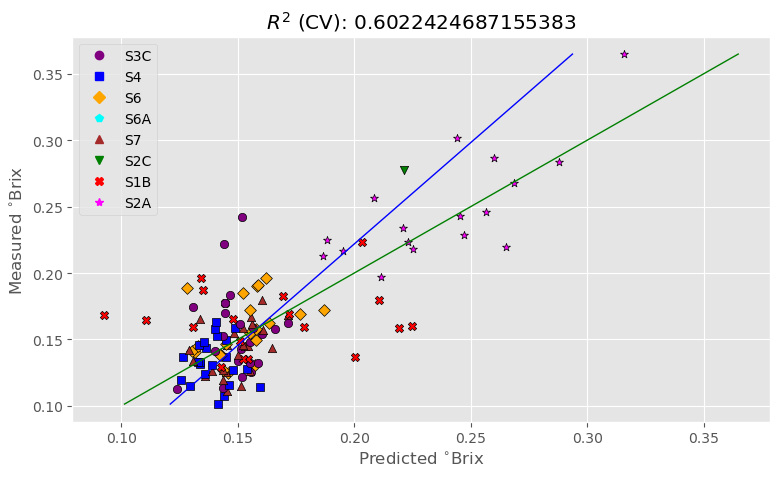

In [18]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# SRA

In [19]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  15
Wavelengths to be kept  53
Optimised MSEP  89.61647897784933



[609.24450069 718.37693189 762.39261427 519.95111465 508.98651558
 577.63128791 566.40623136 715.62505371 574.03640649 616.55587629
 612.46151857 519.46114999 433.77083312 598.10776014 538.34051389
 551.25702534 626.19719811 526.74913438 526.68734102 392.67026583
 704.06622735 507.10579949 283.95648256 323.67893861 226.93842298
 391.02450898 320.67482904 274.25129145 367.10642096 223.92260199
 400.18335459 308.94071237 282.7723211  409.28002337 295.44876595
 212.81512116 570.84259035 529.29333163 459.44548872 497.23286432
 567.7152795  600.96109701 599.87988896 501.19711738 590.02373066
 649.66862383 757.96416906 641.358389   572.74814608 613.51436
 565.95679224 548.50657956 553.8457424  597.56531149 577.62932622
 549.1452134  506.58895729 556.92642944 816.33933024 610.64730041
 482.06920821 549.11575839 524.26842001 543.20834287 533.49008466
 531.83327264 584.52563318 635.64356333 509.38532609 584.86169791
 529.16128094 512.73708092 698.17883262 623.00126294 570.8518017
 527.91842567 

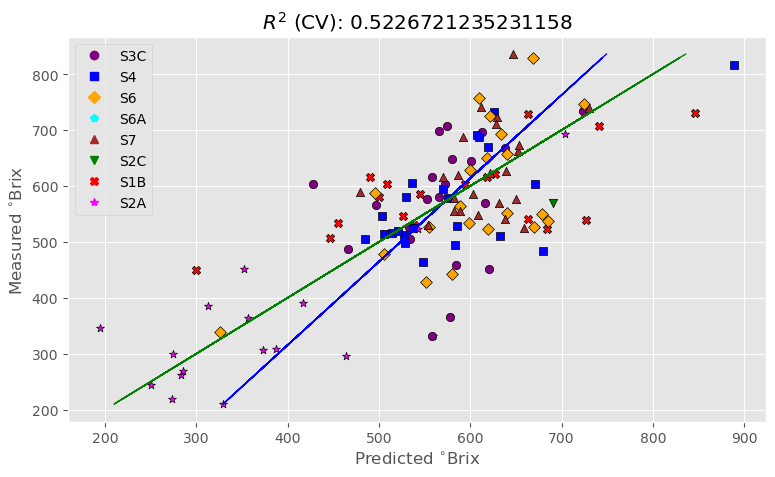

In [20]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## RBD

In [21]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 20)



Optimised number of PLS components:  17
Wavelengths to be kept  25
Optimised MSEP  0.0037048613741976844



[ 0.00464076 -0.00026439  0.00335288  0.00239354  0.00229471 -0.00021383
  0.00245859  0.00395985  0.00568539  0.00262131  0.00627785 -0.00010203
  0.00439319  0.01019626  0.00352949  0.00323583  0.00164264  0.00732126
  0.00521481  0.00175813  0.00246867  0.00256129 -0.00020074  0.00666142
  0.01160904  0.01035158  0.00733475  0.01363085  0.01218694  0.00762725
  0.00812219  0.00483756  0.00984754  0.01006718  0.00617656  0.00857649
  0.01336478  0.00468952  0.01899756  0.00337934  0.00026048  0.01253357
  0.00872347  0.00788311  0.00427433  0.00337575  0.00416084  0.0084934
  0.00511577  0.0035587   0.00917776  0.00668146  0.0042148   0.00576
  0.00606495  0.00580901  0.00867568  0.00471741  0.00519303  0.00619568
  0.00400878  0.0066351   0.00472763  0.00697123  0.00624607  0.00823996
  0.00849273  0.01235019  0.00833908  0.00563738  0.00608144  0.00618366
  0.00575824  0.00789864  0.00605862  0.00886915  0.00647825  0.01092798
  0.00538675  0.00865065  0.0101716   0.00761701  0.005

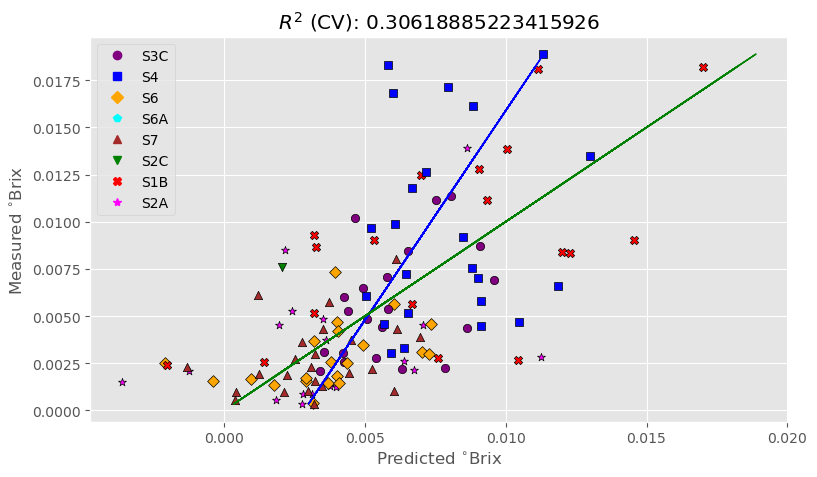

In [22]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [14]:
df_svc_RBD['site'][29]

'S2A_Q17'

## RLD

In [23]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  14
Wavelengths to be kept  56
Optimised MSEP  2.8744181403909486



[-0.6311673   0.96006917  1.13068698  1.55167846  0.54378148  2.78996222
  2.54101579  2.51984187  5.7728835   1.13105836  1.42319385  2.64350345
  5.80905609  2.15064064  2.40829447  2.53770016  1.33008127  2.31657047
  2.63381251  3.18902477  2.46888764  4.11542438  2.16546293  3.70295452
  2.51824418  2.19317579  6.25793462  3.17846296  7.02642507  2.50726459
  3.3514407   2.04817375  3.15313865  3.07774677  5.4996062   6.21995373
  6.06531368  3.34420158  4.6372942   4.35853115  4.827987    4.46512486
  6.08628184  5.13139283  7.25175987  5.11390555  5.28178948  5.91392097
  6.15899784  4.65441758  4.68572452  5.66270224  7.50205462  6.99933512
  4.84112168  3.63047596  4.17295103  5.57580337  7.42927669  6.84408021
  3.98394061  5.79639193  4.43930093  6.59054639  6.23530798  5.72840173
  5.41979928  5.58141581  5.86279952  3.81680278  6.77719929  6.3646609
  6.09519643  8.04132523  8.11732505  5.50325857  7.97605149  6.83516603
  6.02903579  6.76824274  4.71005301  7.93682485  7.

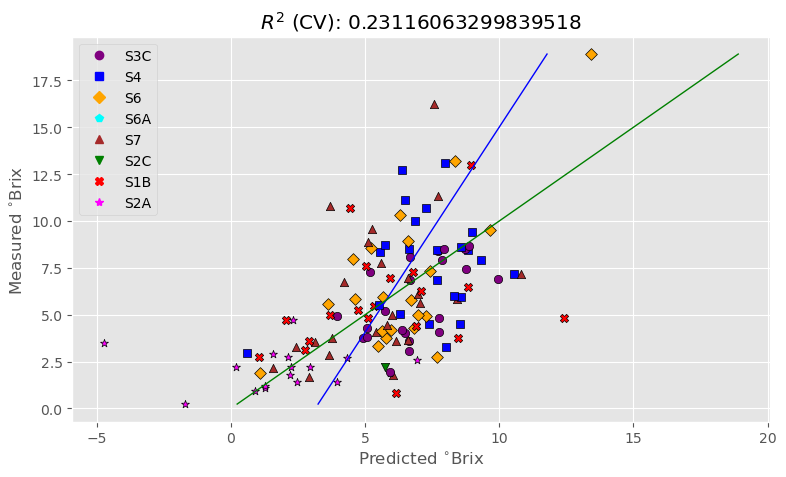

In [24]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [25]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  9
Wavelengths to be kept  69
Optimised MSEP  0.788877802929564



[-28.74058542 -29.03934923 -27.62914107 -28.79532698 -28.69621743
 -29.01583451 -27.51843699 -28.76113022 -28.58593408 -26.86768573
 -27.16442524 -29.35913988 -28.53706856 -27.35658155 -28.29534262
 -27.80261996 -27.59699388 -28.216847   -27.99369752 -26.96883464
 -29.88796356 -26.20759878 -26.79656206 -27.34273806 -26.32467754
 -28.86221157 -28.36077959 -27.79810329 -28.26703998 -28.33596558
 -29.26528059 -27.91526246 -27.37206713 -26.78718883 -28.43634061
 -26.72994764 -27.97736816 -27.30910455 -29.98083484 -28.07070239
 -28.20763876 -26.34325913 -28.18752986 -26.35806843 -28.53228406
 -27.02388956 -28.13317642 -27.27001276 -27.70368034 -27.41815488
 -28.11572786 -27.74303417 -28.28198387 -28.11798876 -27.89323314
 -27.97909839 -27.59242761 -27.38973759 -28.27333923 -27.60865776
 -28.10200871 -27.9179356  -27.86339299 -28.12334404 -28.48456632
 -28.15543261 -27.9948268  -28.30027028 -28.08434377 -28.26684003
 -28.70515268 -28.7222705  -28.14974754 -27.42969722 -28.69025654
 -28.27900

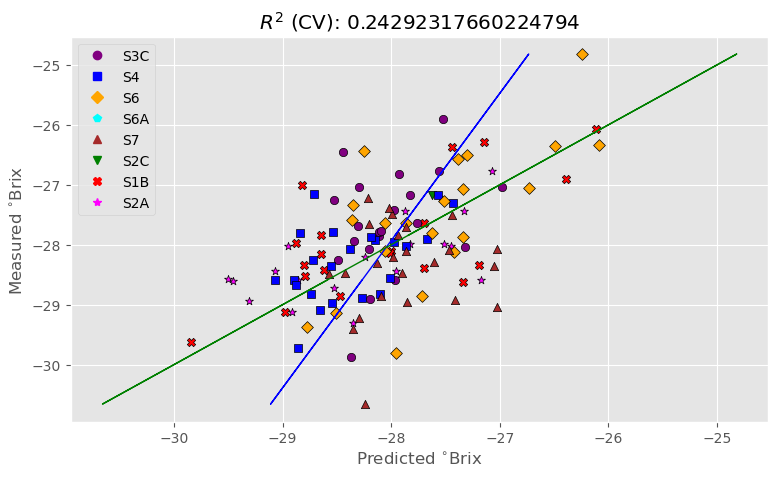

In [26]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  11
Wavelengths to be kept  42
Optimised MSEP  1.6938276890164312

[13.0892973  11.28002249 10.9878518  12.91768498  8.43315675 12.05944505
 10.69377721  8.18752546  8.9430941   7.30072976  6.06432853  7.05975662
 10.94616353  5.83436316  9.53722442  8.57314344  9.48693658  8.79897981
  7.60388474 10.54618282  5.18924371  8.8497329   8.87148467  7.41359499
 10.39076776 11.49687309  8.64871755 10.98515316 10.96931849 13.73878874
 14.51701728  9.65352059  8.26919247 13.12103326 12.56348431 11.26842997
  7.96878224 11.37351837 12.6173866  13.97243987  9.90994777  7.93534649
  9.78736451  8.3761215   8.59517543  7.88677434 10.83716502 12.16896064
 11.77043089  9.40026987  9.57899899  9.32505648 11.13582357 10.10435851
  8.77352501  9.15451248 10.8910905   9.24950233  9.72956134  9.37185875
 10.11313439 11.28164073  9.79614928 10.31893918 10.89792053  9.47341062
 10.73143731  9.43491068 10.68313239 10.17955451 10.77664101 10.35422497
 11.23399532 10.3760

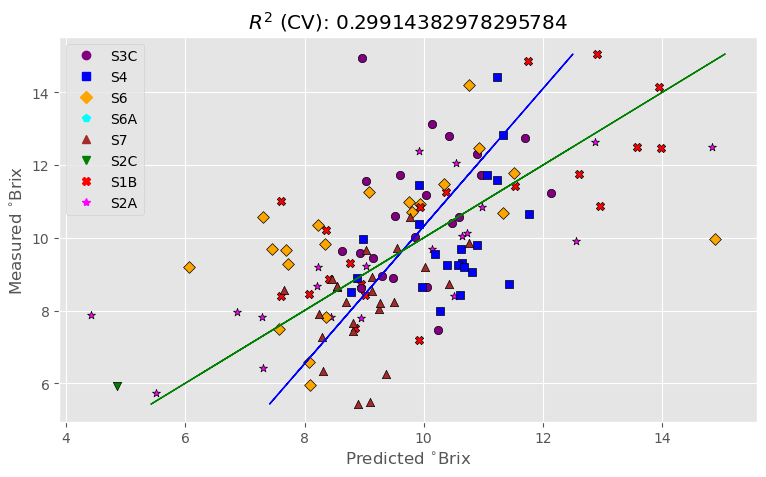

In [27]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  11
Wavelengths to be kept  41
Optimised MSEP  1.3759599186647797

[ 2.77069469e+00 -1.77129885e-01  1.25653934e+00  1.62063195e+00
  1.76908054e+00  1.52406134e+00 -9.92572650e-02 -1.25433240e+00
 -3.03996392e-01 -2.12122075e+00 -1.10775318e+00 -9.38027876e-01
  5.07553108e-01 -4.41614882e+00  2.85736683e-02 -4.41174406e+00
 -8.53249610e-01 -2.11905148e-01 -3.04496315e+00  3.35628938e-01
  1.65816443e+00 -3.22668405e+00  1.68495830e+00  3.93153341e+00
  2.92463620e+00  2.66805497e+00  1.35487630e+00  1.95955574e+00
  1.93461673e+00 -8.09252164e-01  1.13772059e+00  2.44020237e+00
  1.29789878e+00  1.60595110e+00  1.56838717e+00  4.66389236e+00
  2.31116980e+00 -1.16239077e+00 -5.33397075e-01  1.33788800e+00
 -1.41300565e+00  2.34010616e+00  8.98856698e-01 -5.35967450e-01
  1.66343158e+00  7.09958507e-01 -9.34448045e-01 -1.17526688e-01
  1.06279297e+00  4.04524433e-01  1.01125466e+00  1.12988021e-01
  3.38256203e-01  2.29932881e-01 -1.31218167e+00 -4

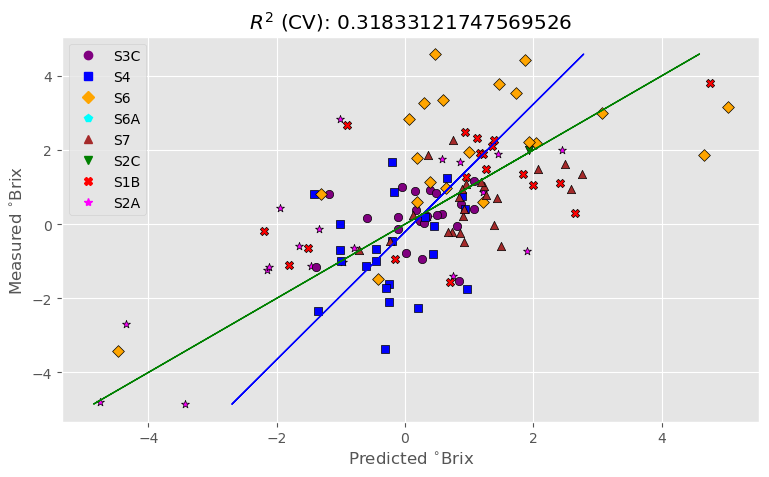

In [28]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  12
Wavelengths to be kept  33
Optimised MSEP  8.69202758259093

[28.88604518 41.91881194 41.18085736 35.01836405 52.40397849 41.48615548
 45.98564952 61.0058343  58.79150381 77.30727452 63.77331428 63.27236748
 47.57330253 84.11841734 48.88470438 65.14079039 60.63524282 58.46199937
 65.44105938 49.22045117 76.85865288 53.02422134 45.59593319 57.30839797
 45.18740416 42.85984979 56.98100234 35.31582977 41.56321903 31.66429792
 27.4024413  46.85899284 58.24653255 30.11196022 38.53150574 48.91757043
 67.05274258 40.12361962 36.14896971 40.26572857 44.07199391 52.41449649
 48.05057227 58.41383    55.00174923 56.92600146 39.07451604 34.42347594
 39.72494045 43.38253647 47.76322631 46.81432484 40.18413121 44.77751456
 49.7614872  53.18092723 46.06450185 49.35506389 46.91641448 49.45295061
 42.87261434 37.67570363 45.18809811 44.88185294 39.44303942 46.93772646
 40.45520399 47.3947525  40.82228276 42.01253023 41.65292593 44.59256844
 42.66315288 46.457449

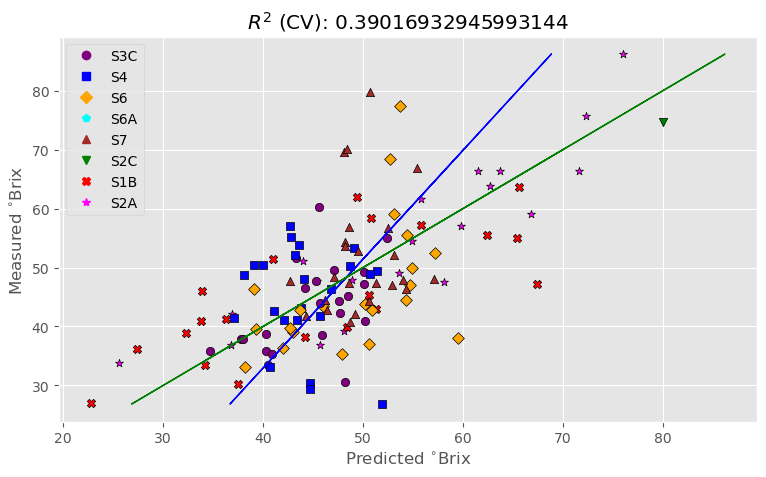

In [29]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  6
Wavelengths to be kept  34
Optimised MSEP  27.461866837795373

[423.83758594 454.37034148 484.60393425 481.41594483 438.90607623
 459.48211665 488.55843183 485.45454232 493.53897052 488.41877191
 543.08480824 472.37686408 501.82042172 489.56519849 472.06330897
 505.84356289 469.44395225 503.98062602 518.1722477  517.12578833
 452.07653389 478.93285799 422.28621864 459.42515064 475.92661739
 464.98738979 479.62891651 403.13224097 426.76691141 427.82023448
 418.21977918 440.40736858 429.80803869 426.65039088 459.4870286
 511.84889279 468.69415011 480.65782126 491.20122876 500.419328
 479.22595955 467.53315315 477.45241514 474.10047864 490.2630302
 449.53846945 409.73792154 446.91911572 467.34987503 433.68459165
 445.1016317  441.30933137 454.80104296 448.7539731  442.037942
 476.65885779 451.93992402 441.92401139 434.36696151 446.69901686
 444.6176331  445.33319115 440.49358422 448.50420362 440.22140285
 450.32883385 436.05615753 446.62846573 430.9

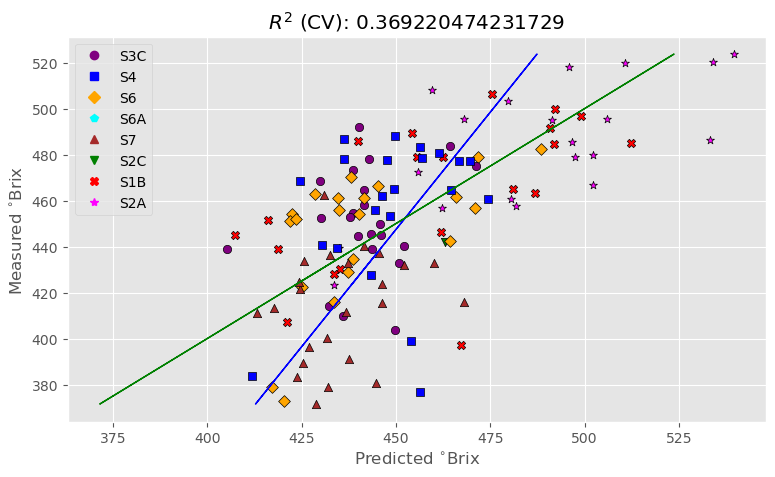

In [30]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
